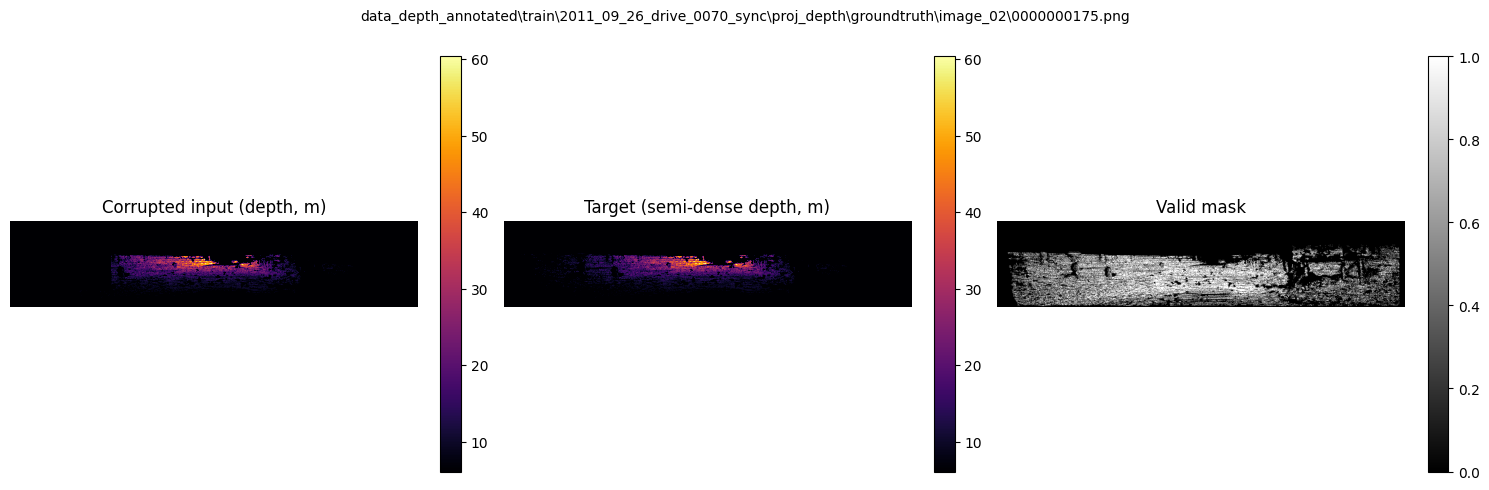

In [37]:
import matplotlib as plt
import numpy as np
from torch.utils.data import Dataset

from utils.data_utils import *


train_loader = get_inpainting_loader(
    annotated_root='data_depth_annotated',
    split='train',
    batch_size=4,
    resize_to=(256,1216), # could otherwise be (256,1216)
    normalize=False
)

val_loader = get_inpainting_loader(
    annotated_root='data_depth_annotated',
    split='val',
    batch_size=4,
    resize_to=(256,1216),# could otherwise be (256,1216)
    shuffle=False,
    normalize=False
)

# Visualize some here

import matplotlib.pyplot as plt
import numpy as np
import torch

batch = next(iter(train_loader))

inp = batch["input_depth"][0,0].numpy()
tgt = batch["target_depth"][0,0].numpy()
mask = batch["valid_mask"][0,0].numpy()
path = batch["path"][0]

# We'll only consider valid pixels for scaling
valid_tgt_vals = tgt[mask]

# Safety in case something is weird
if valid_tgt_vals.size == 0:
    print("No valid depth pixels in this sample? That's unusual.")
    vmin, vmax = 0.0, 80.0
else:
    vmin = np.percentile(valid_tgt_vals, 1)   # robust lower bound
    vmax = np.percentile(valid_tgt_vals, 99)  # robust upper bound

# For display, let's zero-out invalid pixels instead of NaN
inp_disp = np.zeros_like(inp)
tgt_disp = np.zeros_like(tgt)
inp_disp[mask] = inp[mask]
tgt_disp[mask] = tgt[mask]

fig, axs = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(f"{path}", fontsize=10)

#TODO: MIGHT WANT TO MAKE CLOSER POINTS BRIGHTER (THE LOWER VALUE OF M)
im0 = axs[0].imshow(inp_disp, cmap='inferno', vmin=vmin, vmax=vmax)
axs[0].set_title("Corrupted input (depth, m)")
plt.colorbar(im0, ax=axs[0], fraction=0.046)

im1 = axs[1].imshow(tgt_disp, cmap='inferno', vmin=vmin, vmax=vmax)
axs[1].set_title("Target (semi-dense depth, m)")
plt.colorbar(im1, ax=axs[1], fraction=0.046)

#TODO: Replace valid mask with valid mask + holes visible by shading the removed points in red 
im2 = axs[2].imshow(mask.astype(np.float32), cmap='gray', vmin=0, vmax=1)
axs[2].set_title("Valid mask")
plt.colorbar(im2, ax=axs[2], fraction=0.046)

for ax in axs:
    ax.axis('off')

plt.tight_layout()
plt.show()



# # # example train loop
# # for batch in train_loader:
# #     x = batch["input_depth"].cuda()      # [B,1,H,W]
# #     y = batch["target_depth"].cuda()     # [B,1,H,W]
# #     m = batch["valid_mask"].cuda()       # [B,1,H,W] bool

# #     # forward pass
# #     # pred = model(x)

# #     # masked L1 loss
# #     # loss = torch.abs(pred - y)[m].mean()

# #     break


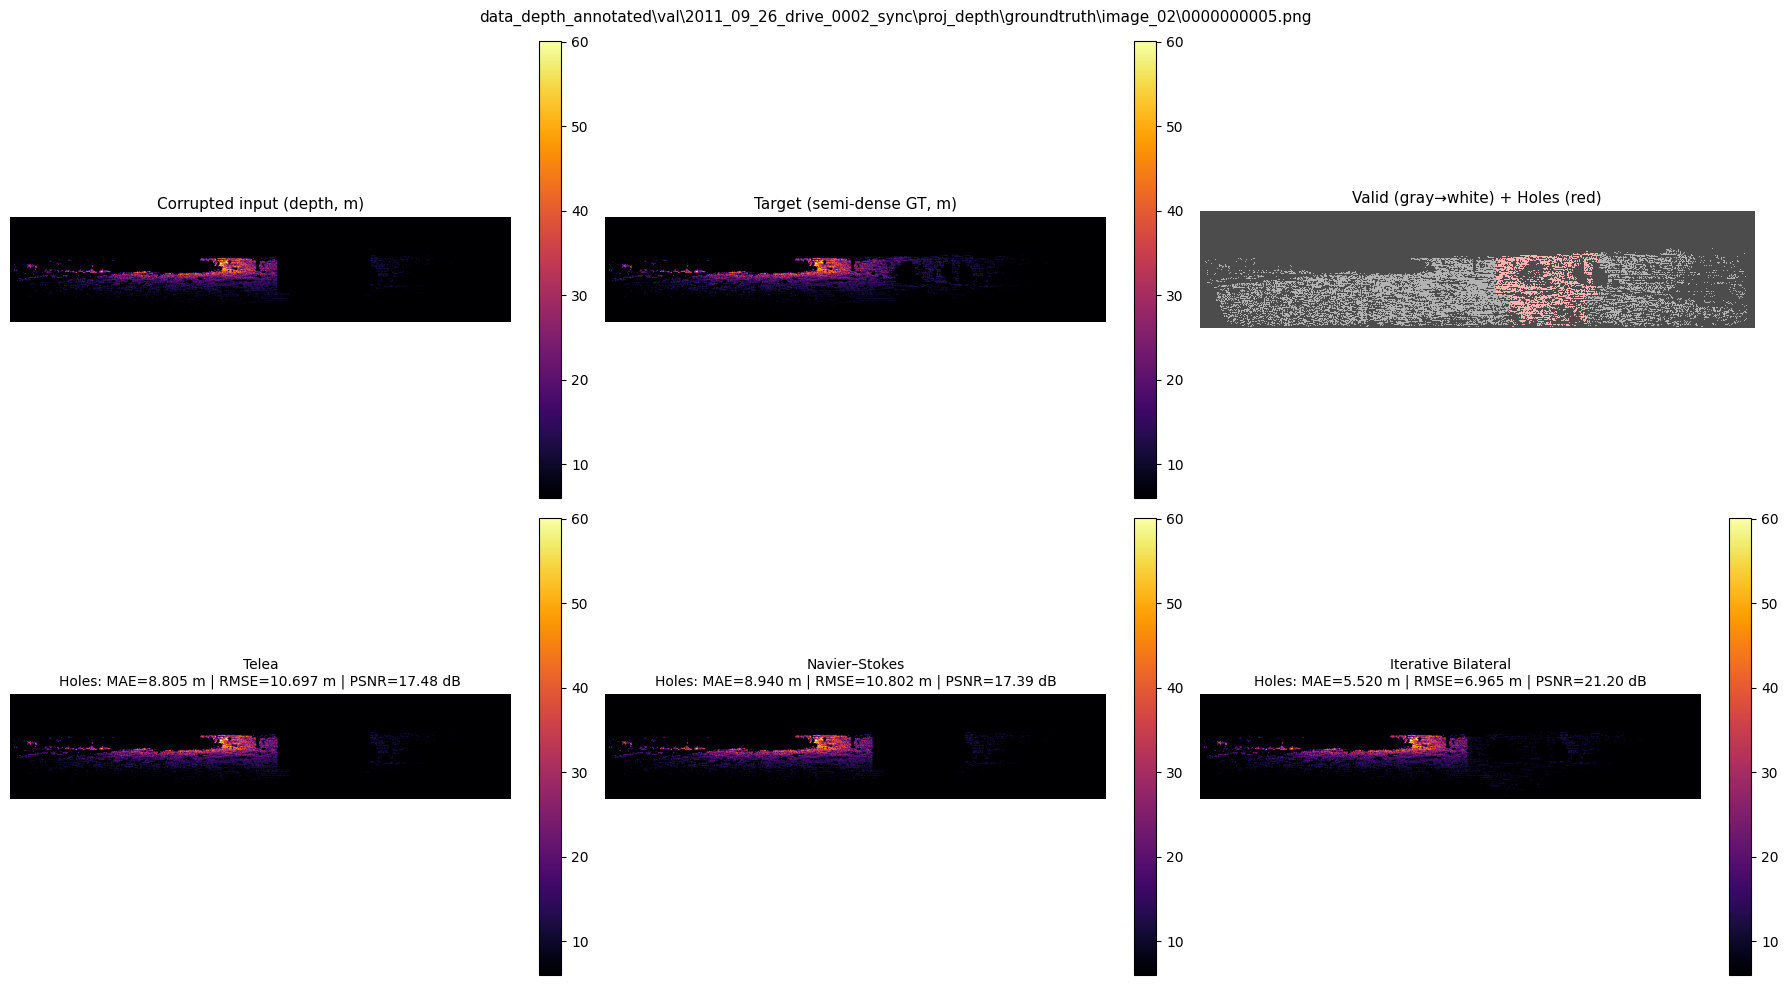

In [38]:
# Image inpainting with classical baselines (TELEA, Navier-Stokes)

# ============================
# Classical baselines + PSNR + 2x3 visualization
# ============================

import cv2
import numpy as np
import torch
import matplotlib.pyplot as plt

# ---------- helpers: scaling, masks, metrics ----------

def compute_scaling(valid_vals):
    """
    Robust per-image scaling range for display or uint8 proxy (OpenCV inpaint).
    Uses 1st-99th percentiles of valid depth (m). Falls back to [0,80].
    """
    if valid_vals.size == 0:
        return 0.0, 80.0
    vmin = float(np.percentile(valid_vals, 1))
    vmax = float(np.percentile(valid_vals, 99))
    if vmax <= vmin:
        vmax = vmin + 1.0
    return vmin, vmax

def depth_to_uchar(depth_m, vmin, vmax):
    """Map meters -> uint8 [0,255] for OpenCV inpaint (clip then scale)."""
    d = np.clip(depth_m, vmin, vmax)
    d = (255.0 * (d - vmin) / (vmax - vmin)).astype(np.uint8)
    return d

def uchar_to_depth(d8, vmin, vmax):
    """Map uint8 [0,255] back to meters using the same vmin/vmax."""
    d8 = d8.astype(np.float32) / 255.0
    return d8 * (vmax - vmin) + vmin

def make_hole_mask(input_depth_m, target_depth_m):
    """
    Holes are where we zeroed a pixel that actually has GT:
      input == 0 (synthetic occlusion) AND target > 0 (KITTI had a measurement)
    """
    return (input_depth_m == 0.0) & (target_depth_m > 0.0)

def mae_rmse_psnr(pred, gt, region_mask, max_val=80.0):
    """
    Compute MAE, RMSE, and PSNR (in dB) over the given boolean region_mask.
    PSNR = 20*log10(max_val / RMSE). For depth, we default to max_val=80m (KITTI cap).
    """
    m = region_mask
    if m.sum() == 0:
        return np.nan, np.nan, np.nan
    err = (pred[m] - gt[m]).astype(np.float32)
    mae = float(np.mean(np.abs(err)))
    rmse = float(np.sqrt(np.mean(err * err)))
    if rmse == 0 or np.isnan(rmse):
        psnr = np.inf
    else:
        psnr = float(20.0 * np.log10(max_val / rmse))
    return mae, rmse, psnr

# ---------- Baseline 1: Telea (Fast Marching) ----------

def inpaint_telea_depth(input_depth_m, target_depth_m, radius_px=3):
    """
    OpenCV Telea inpainting on an 8-bit proxy of depth.
    Only holes (input==0 & target>0) are inpainted; known pixels are kept exact.
    """
    depth = input_depth_m.copy()
    hole_mask = make_hole_mask(input_depth_m, target_depth_m).astype(np.uint8)

    valid_vals = target_depth_m[target_depth_m > 0]
    vmin, vmax = compute_scaling(valid_vals)
    d8 = depth_to_uchar(depth, vmin, vmax)
    mask8 = (hole_mask * 255).astype(np.uint8)

    filled8 = cv2.inpaint(d8, mask8, inpaintRadius=radius_px, flags=cv2.INPAINT_TELEA)
    filled_m = uchar_to_depth(filled8, vmin, vmax)

    # Reinstate known pixels exactly
    known = input_depth_m > 0
    filled_m[known] = input_depth_m[known]
    return filled_m

# ---------- Baseline 2: Navier–Stokes ----------

def inpaint_navier_stokes_depth(input_depth_m, target_depth_m, radius_px=3):
    """
    OpenCV Navier-Stokes (Bertalmio et al.) inpainting on 8-bit proxy.
    Preserves isophotes; slower than Telea.
    """
    depth = input_depth_m.copy()
    hole_mask = make_hole_mask(input_depth_m, target_depth_m).astype(np.uint8)

    valid_vals = target_depth_m[target_depth_m > 0]
    vmin, vmax = compute_scaling(valid_vals)
    d8 = depth_to_uchar(depth, vmin, vmax)
    mask8 = (hole_mask * 255).astype(np.uint8)

    filled8 = cv2.inpaint(d8, mask8, inpaintRadius=radius_px, flags=cv2.INPAINT_NS)
    filled_m = uchar_to_depth(filled8, vmin, vmax)

    known = input_depth_m > 0
    filled_m[known] = input_depth_m[known]
    return filled_m

# ---------- Baseline 3: Iterative edge-aware (bilateral-inpaint) ----------

def bilateral_inpaint_depth(input_depth_m, target_depth_m, iters=8, d=7, sigma_color=3.0, sigma_space=7.0):
    """
    Depth-only iterative fill:
      - Apply bilateral filter to current depth
      - Copy filtered values into holes only
      - Keep known pixels fixed (Dirichlet boundary)
    Repeat 'iters' times.
    """
    depth = input_depth_m.copy()
    hole_mask = make_hole_mask(input_depth_m, target_depth_m)

    if not hole_mask.any():
        return depth

    # Optional seed to avoid flat zero patches creating shocks
    if np.all(depth[hole_mask] == 0):
        known = depth[input_depth_m > 0]
        seed_val = np.median(known) if known.size > 0 else 0.0
        depth[hole_mask] = seed_val

    for _ in range(iters):
        bf = cv2.bilateralFilter(depth.astype(np.float32), d=d, sigmaColor=sigma_color, sigmaSpace=sigma_space)
        depth[hole_mask] = bf[hole_mask]

    known = input_depth_m > 0
    depth[known] = input_depth_m[known]
    return depth

# ---------- 2x3 Visualization with metrics ----------

def visualize_2x3_with_metrics(inp_m, tgt_m, telea_m, ns_m, bilin_m, title="", max_val_for_psnr=80.0):
    """
    2x3 grid:
      Row 1: Corrupted input | Target (GT) | Valid / Holes overlay
      Row 2: Telea (metrics) | Navier–Stokes (metrics) | Bilateral-inpaint (metrics)
    Metrics shown: MAE / RMSE / PSNR (holes-only). Also compute 'all-valid' if you want to print it.
    """
    H, W = tgt_m.shape
    valid_mask = (tgt_m > 0)
    hole_mask  = make_hole_mask(inp_m, tgt_m)

    # Display range from valid GT
    vals = tgt_m[valid_mask]
    vmin, vmax = compute_scaling(vals)

    def disp(d):
        out = np.zeros_like(d)
        out[valid_mask] = d[valid_mask]
        return out

    # Compute metrics (holes-only)
    telea_h = mae_rmse_psnr(telea_m, tgt_m, hole_mask & valid_mask, max_val=max_val_for_psnr)
    ns_h    = mae_rmse_psnr(ns_m, tgt_m, hole_mask & valid_mask, max_val=max_val_for_psnr)
    bilin_h = mae_rmse_psnr(bilin_m, tgt_m, hole_mask & valid_mask, max_val=max_val_for_psnr)

    # Optionally also compute all-valid (not displayed, but handy)
    telea_all = mae_rmse_psnr(telea_m, tgt_m, valid_mask, max_val=max_val_for_psnr)
    ns_all    = mae_rmse_psnr(ns_m, tgt_m, valid_mask, max_val=max_val_for_psnr)
    bilin_all = mae_rmse_psnr(bilin_m, tgt_m, valid_mask, max_val=max_val_for_psnr)

    # Build a nice overlay for holes/valid
    overlay = np.zeros((H, W, 3), dtype=np.float32)
    # valid pixels in gray
    overlay[..., :] = 0.3
    overlay[valid_mask, :] = 0.7
    # holes in red where GT exists but input is zero
    rr, cc = np.where(hole_mask & valid_mask)
    overlay[rr, cc, 0] = 1.0  # red channel

    fig, axs = plt.subplots(2, 3, figsize=(18, 10))  # bigger figure

    # Row 1
    im0 = axs[0,0].imshow(disp(inp_m), cmap="inferno", vmin=vmin, vmax=vmax)
    axs[0,0].set_title("Corrupted input (depth, m)", fontsize=11)
    axs[0,0].axis("off")
    plt.colorbar(im0, ax=axs[0,0], fraction=0.046)

    im1 = axs[0,1].imshow(disp(tgt_m), cmap="inferno", vmin=vmin, vmax=vmax)
    axs[0,1].set_title("Target (semi-dense GT, m)", fontsize=11)
    axs[0,1].axis("off")
    plt.colorbar(im1, ax=axs[0,1], fraction=0.046)

    axs[0,2].imshow(overlay, interpolation="nearest")
    axs[0,2].set_title("Valid (gray→white) + Holes (red)", fontsize=11)
    axs[0,2].axis("off")

    # Row 2: methods + titles with metrics (holes-only)
    def tlabel(name, triplet):
        mae, rmse, psnr = triplet
        return f"{name}\nHoles: MAE={mae:.3f} m | RMSE={rmse:.3f} m | PSNR={psnr:.2f} dB"

    im2 = axs[1,0].imshow(disp(telea_m), cmap="inferno", vmin=vmin, vmax=vmax)
    axs[1,0].set_title(tlabel("Telea", telea_h), fontsize=10)
    axs[1,0].axis("off")
    plt.colorbar(im2, ax=axs[1,0], fraction=0.046)

    im3 = axs[1,1].imshow(disp(ns_m), cmap="inferno", vmin=vmin, vmax=vmax)
    axs[1,1].set_title(tlabel("Navier–Stokes", ns_h), fontsize=10)
    axs[1,1].axis("off")
    plt.colorbar(im3, ax=axs[1,1], fraction=0.046)

    im4 = axs[1,2].imshow(disp(bilin_m), cmap="inferno", vmin=vmin, vmax=vmax)
    axs[1,2].set_title(tlabel("Iterative Bilateral", bilin_h), fontsize=10)
    axs[1,2].axis("off")
    plt.colorbar(im4, ax=axs[1,2], fraction=0.046)

    plt.suptitle(title, fontsize=11)
    plt.tight_layout()
    plt.show()

# ---------- Convenience: run baselines on one sample and visualize ----------

def run_and_show_one(batch, index=0, telea_radius=3, ns_radius=3,
                     bilin_iters=8, bilin_d=7, bilin_sigma_color=3.0, bilin_sigma_space=7.0,
                     psnr_max_val=80.0):
    """
    batch: dict from your DataLoader
    index: which element in the batch to visualize
    """
    inp = batch["input_depth"][index,0].cpu().numpy()
    tgt = batch["target_depth"][index,0].cpu().numpy()
    path = batch["path"][index] if "path" in batch else f"sample {index}"

    telea = inpaint_telea_depth(inp, tgt, radius_px=telea_radius)
    ns    = inpaint_navier_stokes_depth(inp, tgt, radius_px=ns_radius)
    bilin = bilateral_inpaint_depth(inp, tgt, iters=bilin_iters, d=bilin_d,
                                    sigma_color=bilin_sigma_color, sigma_space=bilin_sigma_space)

    visualize_2x3_with_metrics(inp, tgt, telea, ns, bilin, title=str(path), max_val_for_psnr=psnr_max_val)

# ---- Example usage (uncomment to test) ----
batch = next(iter(val_loader))
run_and_show_one(batch, index=0)


In [39]:
# -----------------------
# Losses & Metrics
# -----------------------
def masked_l1(pred, tgt, mask):
    # pred,tgt: (B,1,H,W); mask: (B,1,H,W) bool
    if mask.sum() == 0:
        return pred.new_tensor(0.0)
    diff = (pred - tgt).abs()
    return diff[mask].mean()

def tv_smoothness(pred, focus_mask=None):
    """
    Total-variation smoothness on pred (B,1,H,W).
    If focus_mask is provided (bool), compute only where mask is True (shrunk for gradient dims).
    """
    dx = pred[:, :, :, 1:] - pred[:, :, :, :-1]
    dy = pred[:, :, 1:, :] - pred[:, :, :-1, :]
    if focus_mask is not None:
        m_x = focus_mask[:, :, :, 1:] & focus_mask[:, :, :, :-1]
        m_y = focus_mask[:, :, 1:, :] & focus_mask[:, :, :-1, :]
        if m_x.sum() == 0 and m_y.sum() == 0:
            return pred.new_tensor(0.0)
        loss_x = dx.abs()[m_x].mean() if m_x.any() else pred.new_tensor(0.0)
        loss_y = dy.abs()[m_y].mean() if m_y.any() else pred.new_tensor(0.0)
        return (loss_x + loss_y) * 0.5
    else:
        return 0.5 * (dx.abs().mean() + dy.abs().mean())

def mae_rmse_psnr(pred, tgt, region_mask, max_val=80.0):
    if region_mask.sum() == 0:
        return (math.nan, math.nan, math.nan)
    e = (pred - tgt)[region_mask]
    mae = e.abs().mean().item()
    rmse = torch.sqrt((e**2).mean()).item()
    if rmse == 0 or math.isnan(rmse):
        psnr = float('inf')
    else:
        psnr = 20.0 * math.log10(max_val / rmse)
    return mae, rmse, psnr

# -----------------------
# Train / Eval loops
# -----------------------
@torch.no_grad()
def evaluate(model, loader, device, normalized=False, max_depth_m=80.0):
    model.eval()
    s_h_mae = s_h_rmse = s_h_n = 0.0, 0.0, 0
    s_a_mae = s_a_rmse = s_a_n = 0.0, 0.0, 0
    s_h_psnr = s_a_psnr = 0.0, 0.0
    s_h_mae, s_h_rmse, s_h_psnr = 0.0, 0.0, 0.0
    s_a_mae, s_a_rmse, s_a_psnr = 0.0, 0.0, 0.0
    count = 0

    max_val = 1.0 if normalized else max_depth_m

    for batch in loader:
        inp = batch["input_depth"].to(device)   # (B,1,H,W)
        tgt = batch["target_depth"].to(device)
        vm  = batch["valid_mask"].to(device)    # bool
        # Holes are where input==0 but GT exists
        hole_mask = (inp == 0.0) & vm

        pred = model(inp)

        # if normalized=False, predictions are in meters; else in [0,1]
        # metrics
        mae_h, rmse_h, psnr_h = mae_rmse_psnr(pred, tgt, hole_mask, max_val=max_val)
        mae_a, rmse_a, psnr_a = mae_rmse_psnr(pred, tgt, vm,        max_val=max_val)

        # accumulate
        if not math.isnan(mae_h):
            s_h_mae += mae_h; s_h_rmse += rmse_h; s_h_psnr += psnr_h
        if not math.isnan(mae_a):
            s_a_mae += mae_a; s_a_rmse += rmse_a; s_a_psnr += psnr_a
        count += 1

    return {
        "holes_mae":  s_h_mae / max(count,1),
        "holes_rmse": s_h_rmse / max(count,1),
        "holes_psnr": s_h_psnr / max(count,1),
        "all_mae":    s_a_mae / max(count,1),
        "all_rmse":   s_a_rmse / max(count,1),
        "all_psnr":   s_a_psnr / max(count,1),
    }

from tqdm import tqdm


def train_unet(
    train_loader, val_loader,
    model,
    epochs=8, lr=1e-3,
    lambda_holes=2.0, beta_tv=0.01,
    normalized=False, max_depth_m=80.0,
    ckpt_path="unet_depth_inpaint_best.pt",
    device=None,
):
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-6)
    scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())

    history = {
        "train_L_all": [], "train_L_hole": [], "train_L_tv": [],
        "val_holes_rmse": [], "val_holes_mae": [], "val_holes_psnr": [],
        "val_all_rmse": [],   "val_all_mae": [],   "val_all_psnr": []
    }

    best_rmse = float('inf')

    for ep in range(1, epochs+1):
        model.train()
        s_all = s_h = s_tv = 0.0
        nsteps = 0

        for batch in tqdm(train_loader):
            inp = batch["input_depth"].to(device)
            tgt = batch["target_depth"].to(device)
            vm  = batch["valid_mask"].to(device)
            hole_mask = (inp == 0.0) & vm

            opt.zero_grad(set_to_none=True)
            with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
                pred  = model(inp)
                L_all = masked_l1(pred, tgt, vm)
                L_h   = masked_l1(pred, tgt, hole_mask) if hole_mask.any() else pred.new_tensor(0.0)
                L_tv  = tv_smoothness(pred, focus_mask=hole_mask | vm) * beta_tv
                loss  = L_all + lambda_holes * L_h + L_tv

            scaler.scale(loss).backward()
            scaler.step(opt)
            scaler.update()

            s_all += float(L_all.detach()); s_h += float(L_h.detach()); s_tv += float(L_tv.detach())
            nsteps += 1

        # validation
        val = evaluate(model, val_loader, device, normalized=normalized, max_depth_m=max_depth_m)

        # history
        history["train_L_all"].append(s_all / max(1,nsteps))
        history["train_L_hole"].append(s_h  / max(1,nsteps))
        history["train_L_tv"].append(s_tv   / max(1,nsteps))
        history["val_holes_rmse"].append(val["holes_rmse"]); history["val_holes_mae"].append(val["holes_mae"]); history["val_holes_psnr"].append(val["holes_psnr"])
        history["val_all_rmse"].append(val["all_rmse"]);     history["val_all_mae"].append(val["all_mae"]);     history["val_all_psnr"].append(val["all_psnr"])

        # save best on holes RMSE
        if val["holes_rmse"] < best_rmse:
            best_rmse = val["holes_rmse"]
            torch.save({"model": model.state_dict(), "epoch": ep, "val": val,
                        "cfg": {"lambda_holes":lambda_holes, "beta_tv":beta_tv, "normalized":normalized}},
                       ckpt_path)

        print(f"[Epoch {ep}/{epochs}]  "
              f"train: L_all={history['train_L_all'][-1]:.4f}  L_h={history['train_L_hole'][-1]:.4f}  L_tv={history['train_L_tv'][-1]:.4f}  |  "
              f"VAL (holes): RMSE={val['holes_rmse']:.3f}  MAE={val['holes_mae']:.3f}  PSNR={val['holes_psnr']:.2f}  |  "
              f"(all): RMSE={val['all_rmse']:.3f}  MAE={val['all_mae']:.3f}  PSNR={val['all_psnr']:.2f}")

    print(f"Best hole RMSE: {best_rmse:.3f}  (saved to {ckpt_path})")
    return model, history

def plot_training_history(history, title_suffix=""):
    epochs = np.arange(1, len(history["train_L_all"])+1)

    fig, axs = plt.subplots(1, 2, figsize=(14,5))
    # Left: training losses
    axs[0].plot(epochs, history["train_L_all"],  label="L_all (L1@valid)")
    axs[0].plot(epochs, history["train_L_hole"], label="L_hole (L1@holes)")
    axs[0].plot(epochs, history["train_L_tv"],   label="L_tv (TV)")
    axs[0].set_title(f"Training losses{title_suffix}")
    axs[0].set_xlabel("Epoch"); axs[0].set_ylabel("Loss"); axs[0].grid(True); axs[0].legend()

    # Right: validation metrics (holes-focused)
    axs[1].plot(epochs, history["val_holes_rmse"], label="VAL holes RMSE")
    axs[1].plot(epochs, history["val_all_rmse"],   label="VAL all RMSE", linestyle="--")
    axs[1].set_title(f"Validation RMSE{title_suffix}")
    axs[1].set_xlabel("Epoch"); axs[1].set_ylabel("RMSE (m)"); axs[1].grid(True); axs[1].legend()

    plt.tight_layout(); plt.show()

# ----------------
# Training Loaders
# ----------------
# Match to dataloader config:
# - If you used normalize=False in dataset, leave normalized=False here and set max_depth_m=80.
# - If normalize=True, set normalized=True and metrics/PSNR will use max_val=1.0.


import numpy as np
import torch
from torch.utils.data import DataLoader, Subset

# Build full datasets (same args already used)
ds_train = KITTIDepthInpaintingDataset(
    annotated_root='data_depth_annotated',
    split='train',
    resize_to=(256,1216),
    normalize=True
)

ds_val = KITTIDepthInpaintingDataset(
    annotated_root='data_depth_annotated',
    split='val',
    resize_to=(256,1216),
    normalize=True
)

# Take a random 25% (or cap by a fixed N for even faster tests)
rng = np.random.RandomState(42) # reproducible subset
train_frac = 0.25                       
val_frac = 0.2               
n_train = max(1, int(len(ds_train) * train_frac))
n_val = max(1, int(len(ds_val) * val_frac))       # or keep full val if you want

train_idx = rng.choice(len(ds_train), n_train, replace=False)
val_idx = rng.choice(len(ds_val),   n_val,   replace=False)

sub_train = Subset(ds_train, train_idx)
sub_val   = Subset(ds_val,   val_idx)

# Build test set as the remainder of ds_val -
all_val_idx  = np.arange(len(ds_val))
test_idx = np.setdiff1d(all_val_idx, val_idx, assume_unique=False)

sub_test = Subset(ds_val, test_idx)

# Optional: print split sizes to verify no overlap and full coverage
print(f"VAL subset: {len(sub_val)}")
print(f"TEST (remainder): {len(sub_test)}")
print(f"VAL+TEST == full val? {len(sub_val)+len(sub_test) == len(ds_val)}")


# DataLoaders (tune num_workers for your machine)
train_loader = DataLoader(
    sub_train,
    batch_size=4,              # try 4/6/8 if VRAM allows
    shuffle=True
)

val_loader = DataLoader(
    sub_val,
    batch_size=4,
    shuffle=False
)

test_loader = DataLoader(
    sub_test,
    batch_size=4,
    shuffle=False
)


VAL subset: 1370
TEST (remainder): 5482
VAL+TEST == full val? True


In [40]:
#---------------
# TRAIN MODEL #
#---------------

from models import DepthUNet, DepthAutoencoder

model = DepthUNet(in_ch=1, base_ch=32).to(device)
print(f"Train subset: {len(sub_train)} / {len(ds_train)}  |  Val subset: {len(sub_val)} / {len(ds_val)}")


model, history = train_unet(train_loader, val_loader, model,
                   epochs=6, lr=1e-3,
                   lambda_holes=2.0, beta_tv=0.00,
                   normalized=True, max_depth_m=80.0,
                   ckpt_path="unet_epoch6_frac25_no-TV.pt")


# Save history library as a json file 
import json
file_path = "training_history.json"
with open(file_path, "w") as f:
    json.dump(history, f, indent=4)

C:\Users\Jagri\AppData\Local\Temp\ipykernel_25852\1881318602.py:100: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())


Train subset: 21474 / 85898  |  Val subset: 1370 / 6852


  0%|          | 0/5369 [00:00<?, ?it/s]C:\Users\Jagri\AppData\Local\Temp\ipykernel_25852\1881318602.py:122: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
100%|██████████| 5369/5369 [37:00<00:00,  2.42it/s]


[Epoch 1/6]  train: L_all=0.0325  L_h=0.0528  L_tv=0.0000  |  VAL (holes): RMSE=0.088  MAE=0.050  PSNR=21.27  |  (all): RMSE=0.053  MAE=0.027  PSNR=25.64


100%|██████████| 5369/5369 [28:57<00:00,  3.09it/s]


...

[Epoch 4/6]  train: L_all=0.0164  L_h=0.0363  L_tv=0.0000  |  VAL (holes): RMSE=0.076  MAE=0.037  PSNR=22.58  |  (all): RMSE=0.041  MAE=0.015  PSNR=28.02


100%|██████████| 5369/5369 [27:39<00:00,  3.24it/s]


[Epoch 5/6]  train: L_all=0.0156  L_h=0.0351  L_tv=0.0000  |  VAL (holes): RMSE=0.077  MAE=0.037  PSNR=22.50  |  (all): RMSE=0.041  MAE=0.015  PSNR=27.98


100%|██████████| 5369/5369 [30:30<00:00,  2.93it/s]


[Epoch 6/6]  train: L_all=0.0150  L_h=0.0345  L_tv=0.0000  |  VAL (holes): RMSE=0.077  MAE=0.036  PSNR=22.52  |  (all): RMSE=0.041  MAE=0.015  PSNR=27.99
Best hole RMSE: 0.076  (saved to unet_epoch6_frac25_no-TV.pt)


In [41]:
#-------------------------
# WARM START TRAIN MODEL #
#-------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"

# Recreate the exact same architecture
model = DepthAutoencoder(in_ch=1, base_ch=32).to(device)

ckpt = torch.load("autoencoder_depth_inpaint_best.pt", map_location=device)
model.load_state_dict(ckpt["model"])
print("Loaded pretrained weights from epoch", ckpt.get("epoch", "unknown"))


def finetune_unet(model,
    train_loader, val_loader,
    epochs=5, 
    lr=5e-4, # lower LR for finetuning
    lambda_holes=2.0, beta_tv=0.01,
    normalized=False, max_depth_m=80.0,
    ckpt_path="unet_depth_inpaint_finetuned.pt",
    device=None,
):
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    model.train()
    
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-6)
    scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())

    history = {
        "train_L_all": [], "train_L_hole": [], "train_L_tv": [],
        "val_holes_rmse": [], "val_holes_mae": [], "val_holes_psnr": [],
        "val_all_rmse": [],   "val_all_mae": [],   "val_all_psnr": []
    }

    best_rmse = float('inf')

    for ep in range(1, epochs+1):
        model.train()
        s_all = s_h = s_tv = 0.0
        nsteps = 0

        for batch in tqdm(train_loader):
            inp = batch["input_depth"].to(device)
            tgt = batch["target_depth"].to(device)
            vm  = batch["valid_mask"].to(device)
            hole_mask = (inp == 0.0) & vm

            opt.zero_grad(set_to_none=True)
            with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
                pred  = model(inp)
                L_all = masked_l1(pred, tgt, vm)
                L_h   = masked_l1(pred, tgt, hole_mask) if hole_mask.any() else pred.new_tensor(0.0)
                L_tv  = tv_smoothness(pred, focus_mask=hole_mask | vm) * beta_tv
                loss  = L_all + lambda_holes * L_h + L_tv

            scaler.scale(loss).backward()
            scaler.step(opt)
            scaler.update()

            s_all += float(L_all.detach()); s_h += float(L_h.detach()); s_tv += float(L_tv.detach())
            nsteps += 1

        # validation
        val = evaluate(model, val_loader, device, normalized=normalized, max_depth_m=max_depth_m)

        # history
        history["train_L_all"].append(s_all / max(1,nsteps))
        history["train_L_hole"].append(s_h  / max(1,nsteps))
        history["train_L_tv"].append(s_tv   / max(1,nsteps))
        history["val_holes_rmse"].append(val["holes_rmse"]); history["val_holes_mae"].append(val["holes_mae"]); history["val_holes_psnr"].append(val["holes_psnr"])
        history["val_all_rmse"].append(val["all_rmse"]);     history["val_all_mae"].append(val["all_mae"]);     history["val_all_psnr"].append(val["all_psnr"])

        # save best on holes RMSE
        if val["holes_rmse"] < best_rmse:
            best_rmse = val["holes_rmse"]
            torch.save({"model": model.state_dict(), "epoch": ep, "val": val,
                        "cfg": {"lambda_holes":lambda_holes, "beta_tv":beta_tv, "normalized":normalized}},
                       ckpt_path)

        print(f"[FINETUNE Epoch {ep}/{epochs}]  "
              f"train: L_all={history['train_L_all'][-1]:.4f}  L_h={history['train_L_hole'][-1]:.4f}  L_tv={history['train_L_tv'][-1]:.4f}  |  "
              f"VAL (holes): RMSE={val['holes_rmse']:.3f}  MAE={val['holes_mae']:.3f}  PSNR={val['holes_psnr']:.2f}  |  "
              f"(all): RMSE={val['all_rmse']:.3f}  MAE={val['all_mae']:.3f}  PSNR={val['all_psnr']:.2f}")

    print(f"[Finetune] Best hole RMSE: {best_rmse:.3f}  (saved to {ckpt_path})")
    return model, history



Loaded pretrained weights from epoch 6


In [42]:
# -----------------
# RUN FINE TUNING #
# -----------------

print(f"Train subset: {len(sub_train)} / {len(ds_train)}  |  Val subset: {len(sub_val)} / {len(ds_val)}")

finetuned_model, ft_history = finetune_unet(
    model,
    train_loader, val_loader,
    epochs=5,              
    lr=5e-4,          
    lambda_holes=2.0,
    beta_tv=0.01,
    normalized=True,
    max_depth_m=80.0,
    ckpt_path="autoencoder_depth_inpaint_frac50_finetuned.pt",
)

# Save history library as a json file 
import json
file_path = "autoencoder_finetuned_training_history.json"
with open(file_path, "w") as f:
    json.dump(ft_history, f, indent=4)

C:\Users\Jagri\AppData\Local\Temp\ipykernel_25852\3371884219.py:28: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())


Train subset: 21474 / 85898  |  Val subset: 1370 / 6852


  0%|          | 0/5369 [00:00<?, ?it/s]C:\Users\Jagri\AppData\Local\Temp\ipykernel_25852\3371884219.py:50: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
 28%|██▊       | 1504/5369 [07:28<19:13,  3.35it/s]


KeyboardInterrupt: 

In [ ]:
# Save history library as a json file 
import json
file_path = "autoencoder_finetuned_training_history.json"
with open(file_path, "w") as f:
    json.dump(ft_history, f, indent=4)

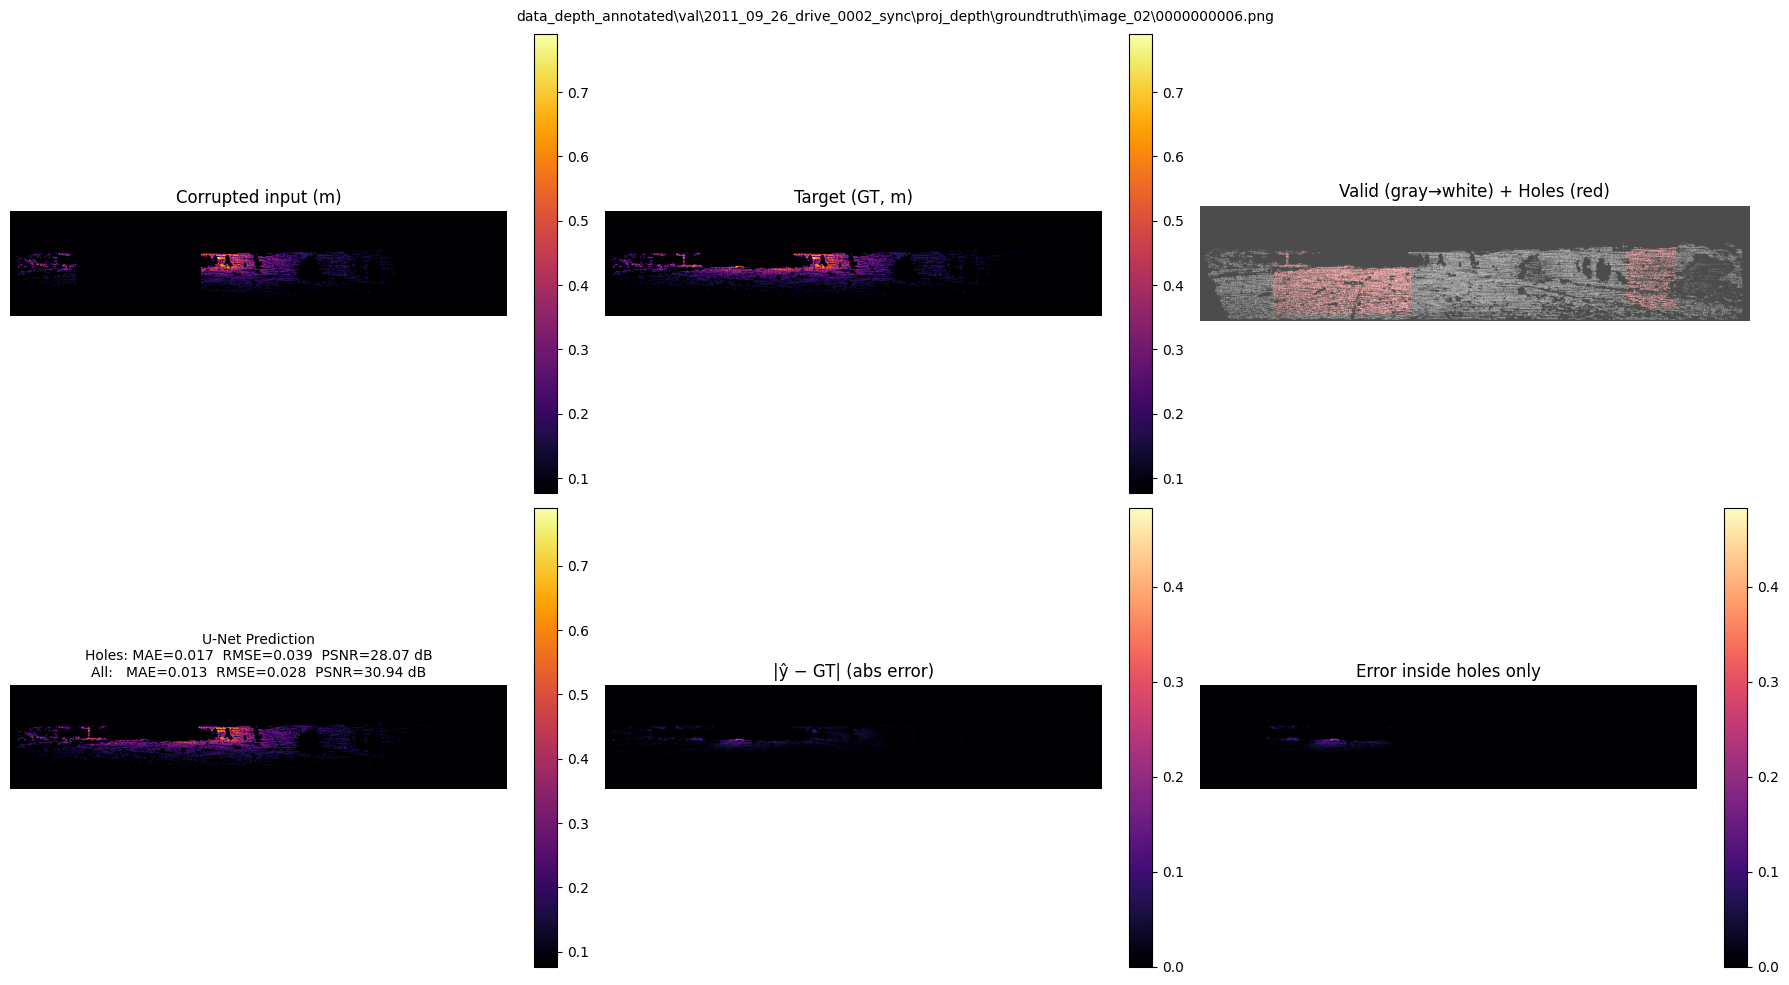

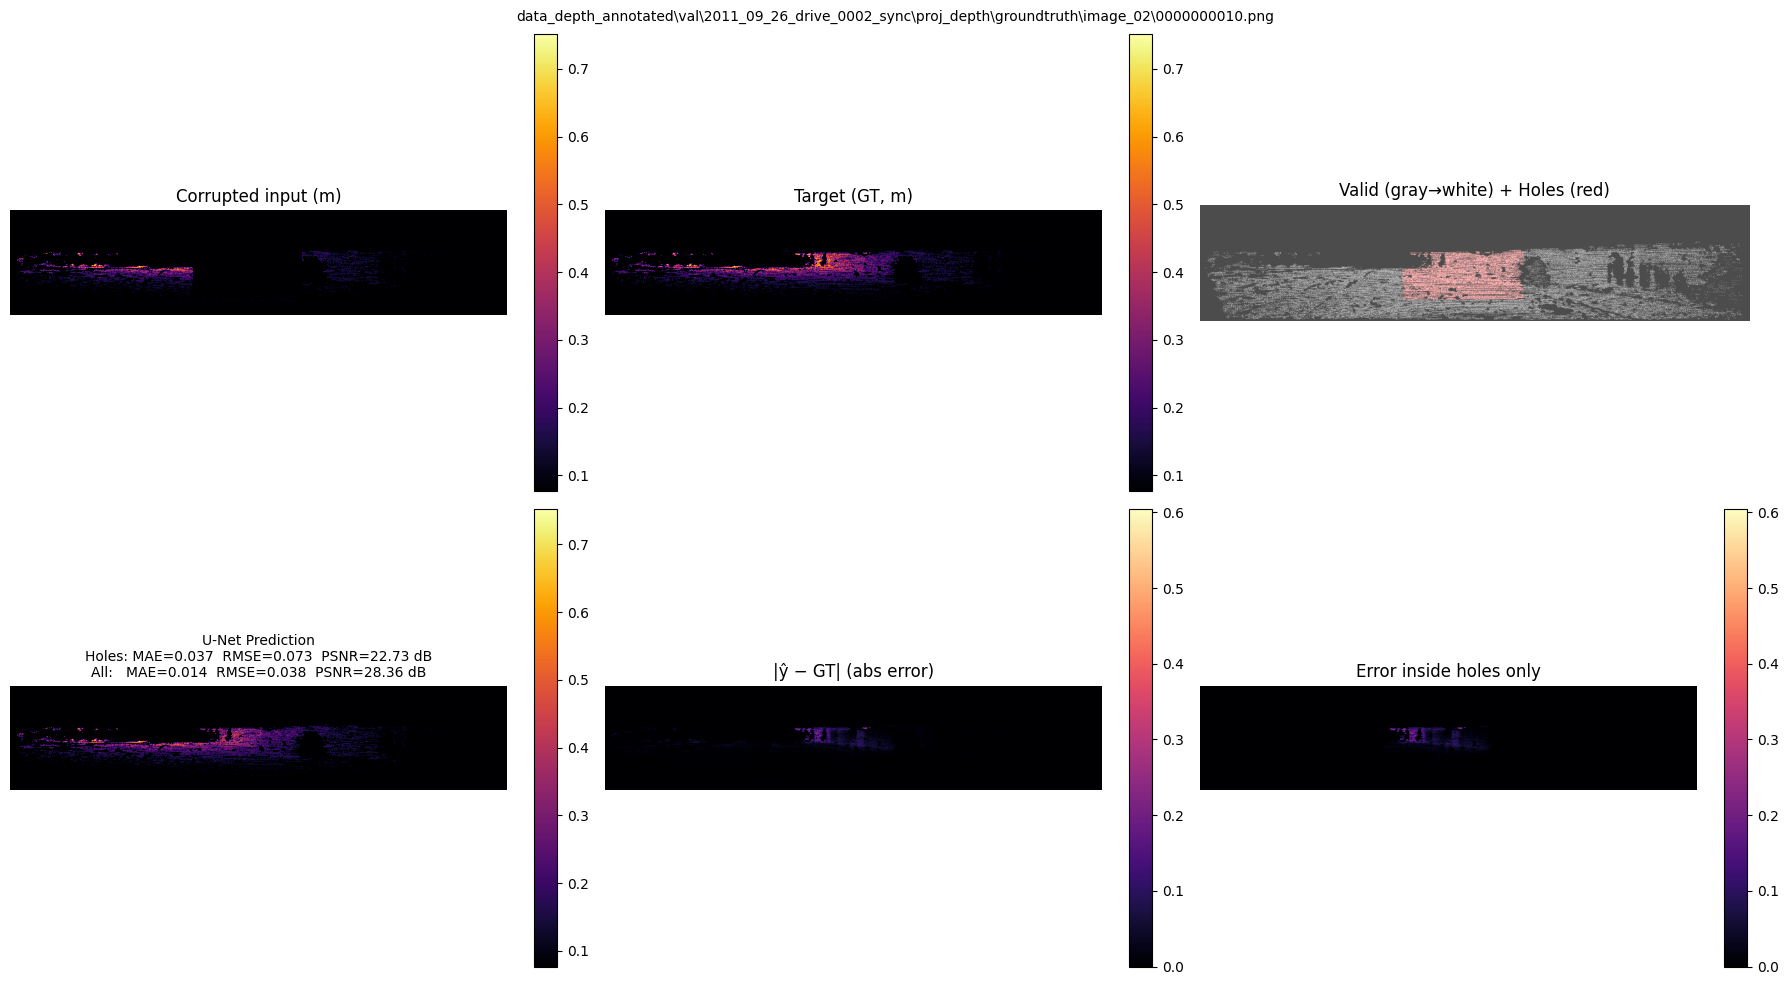

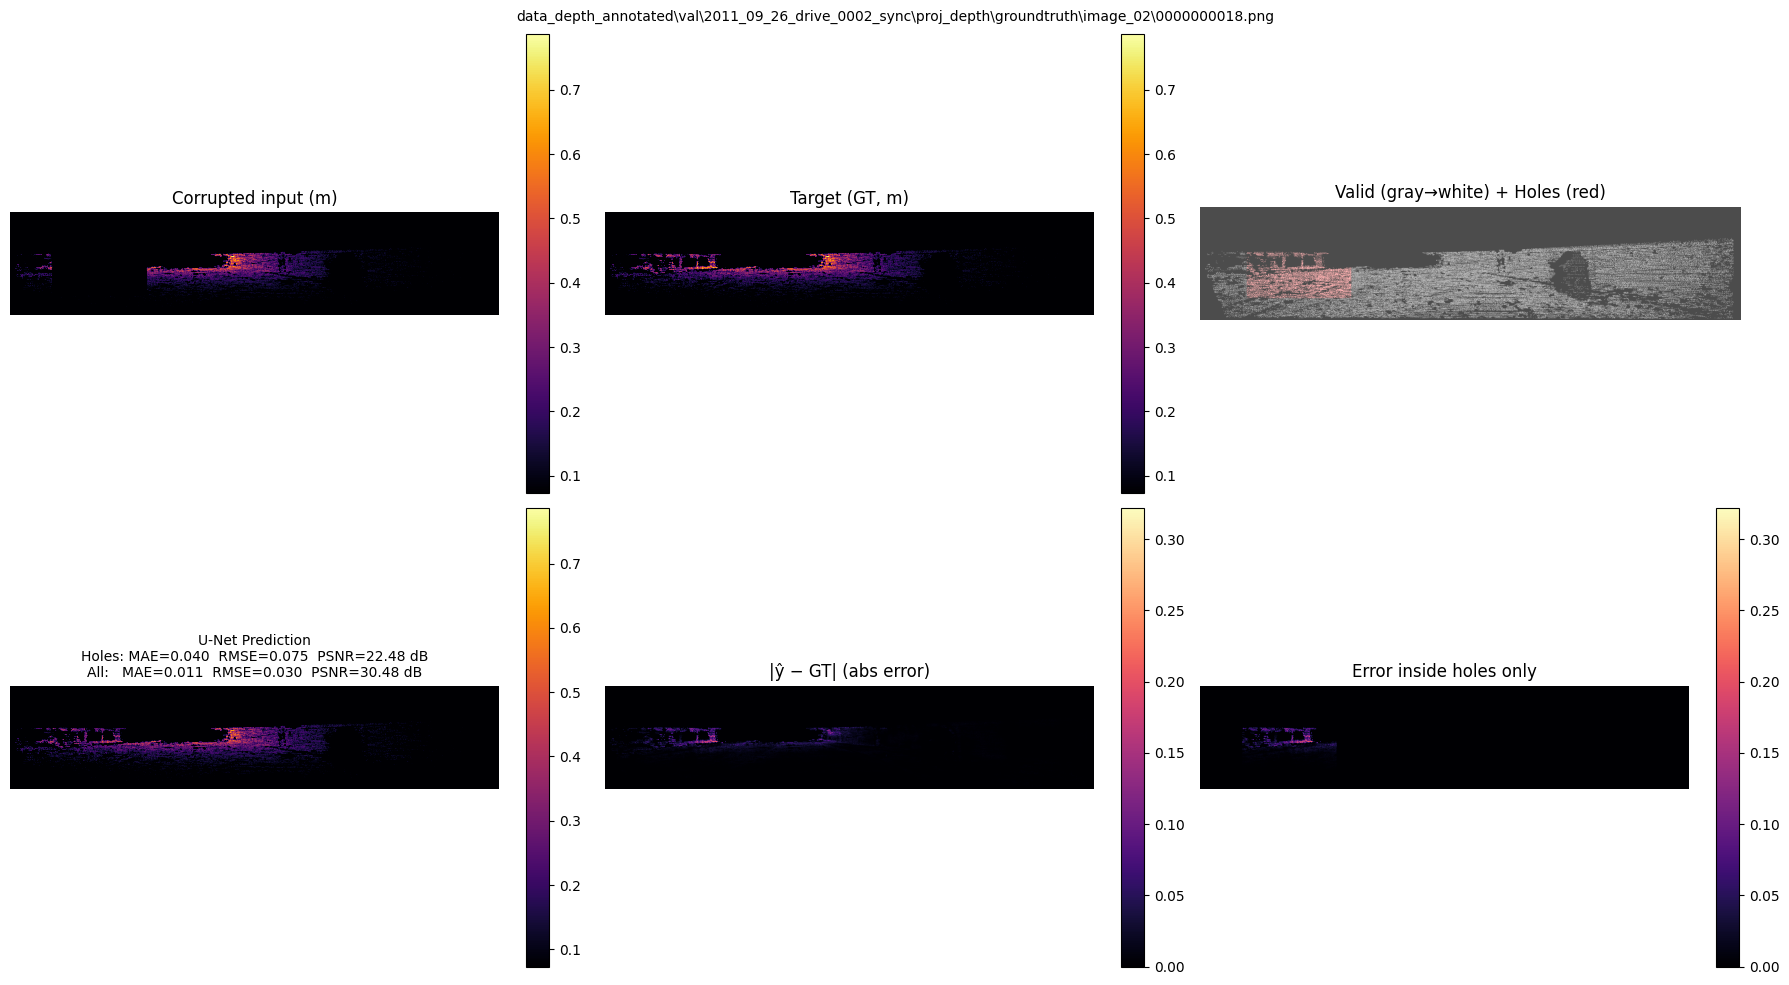

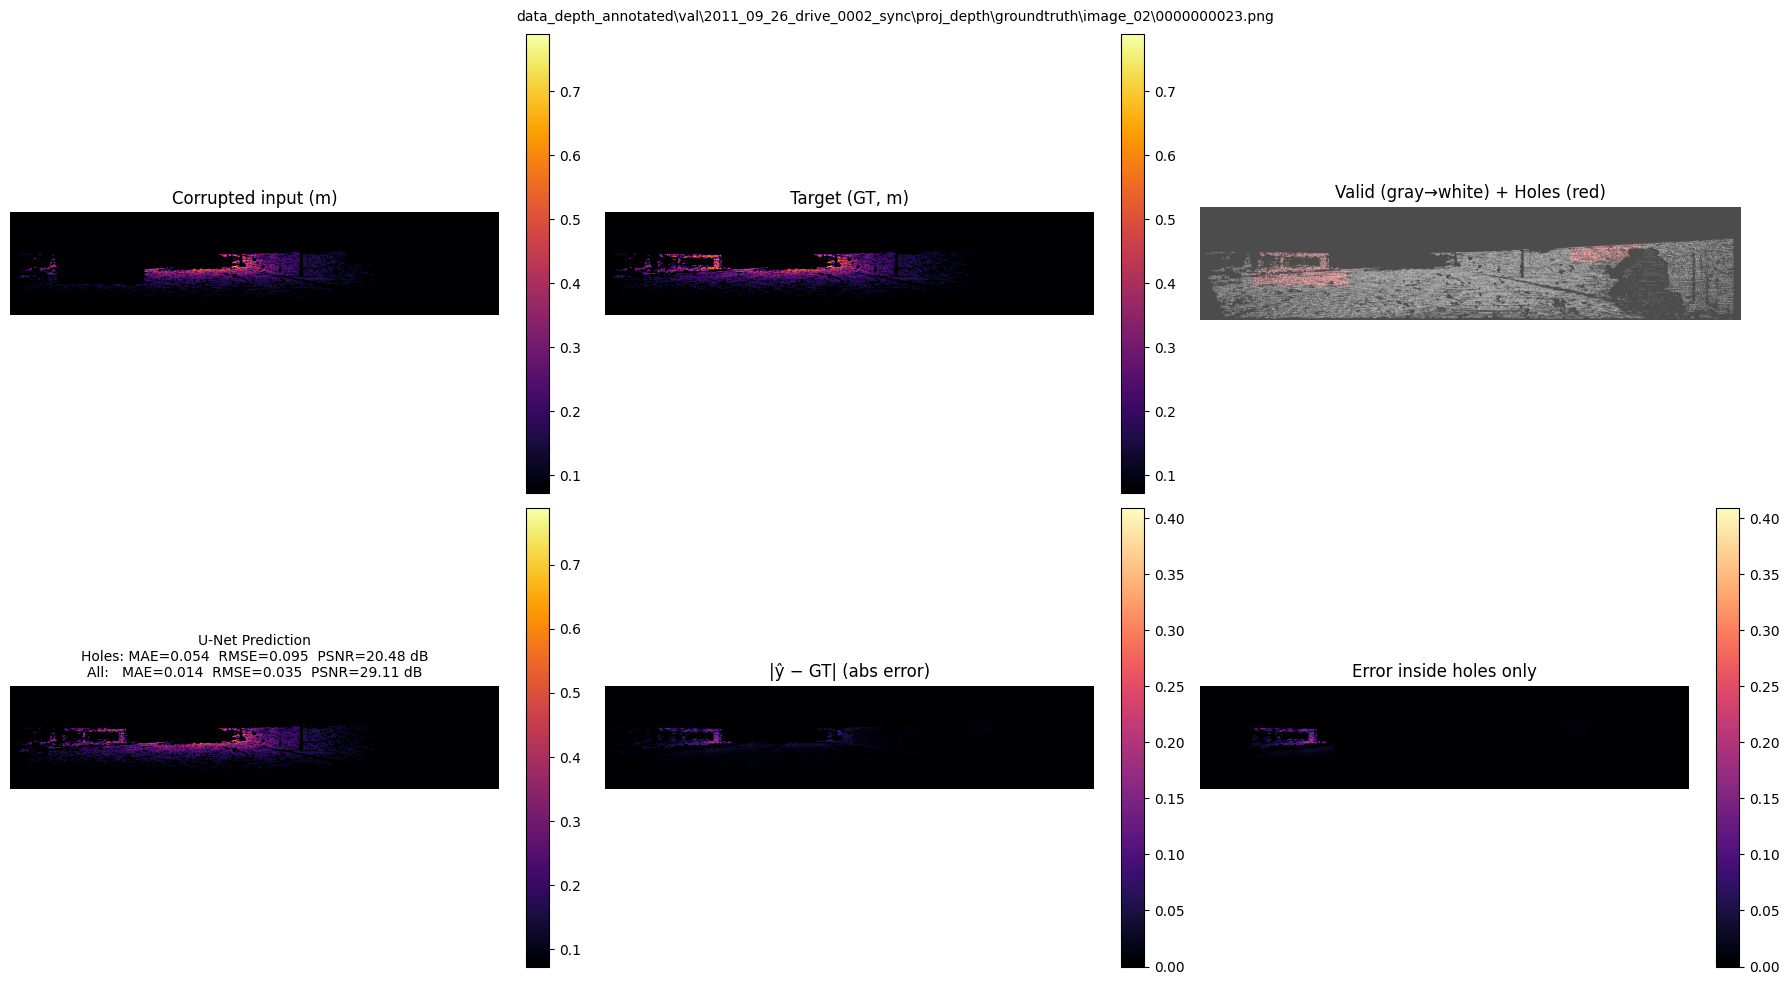

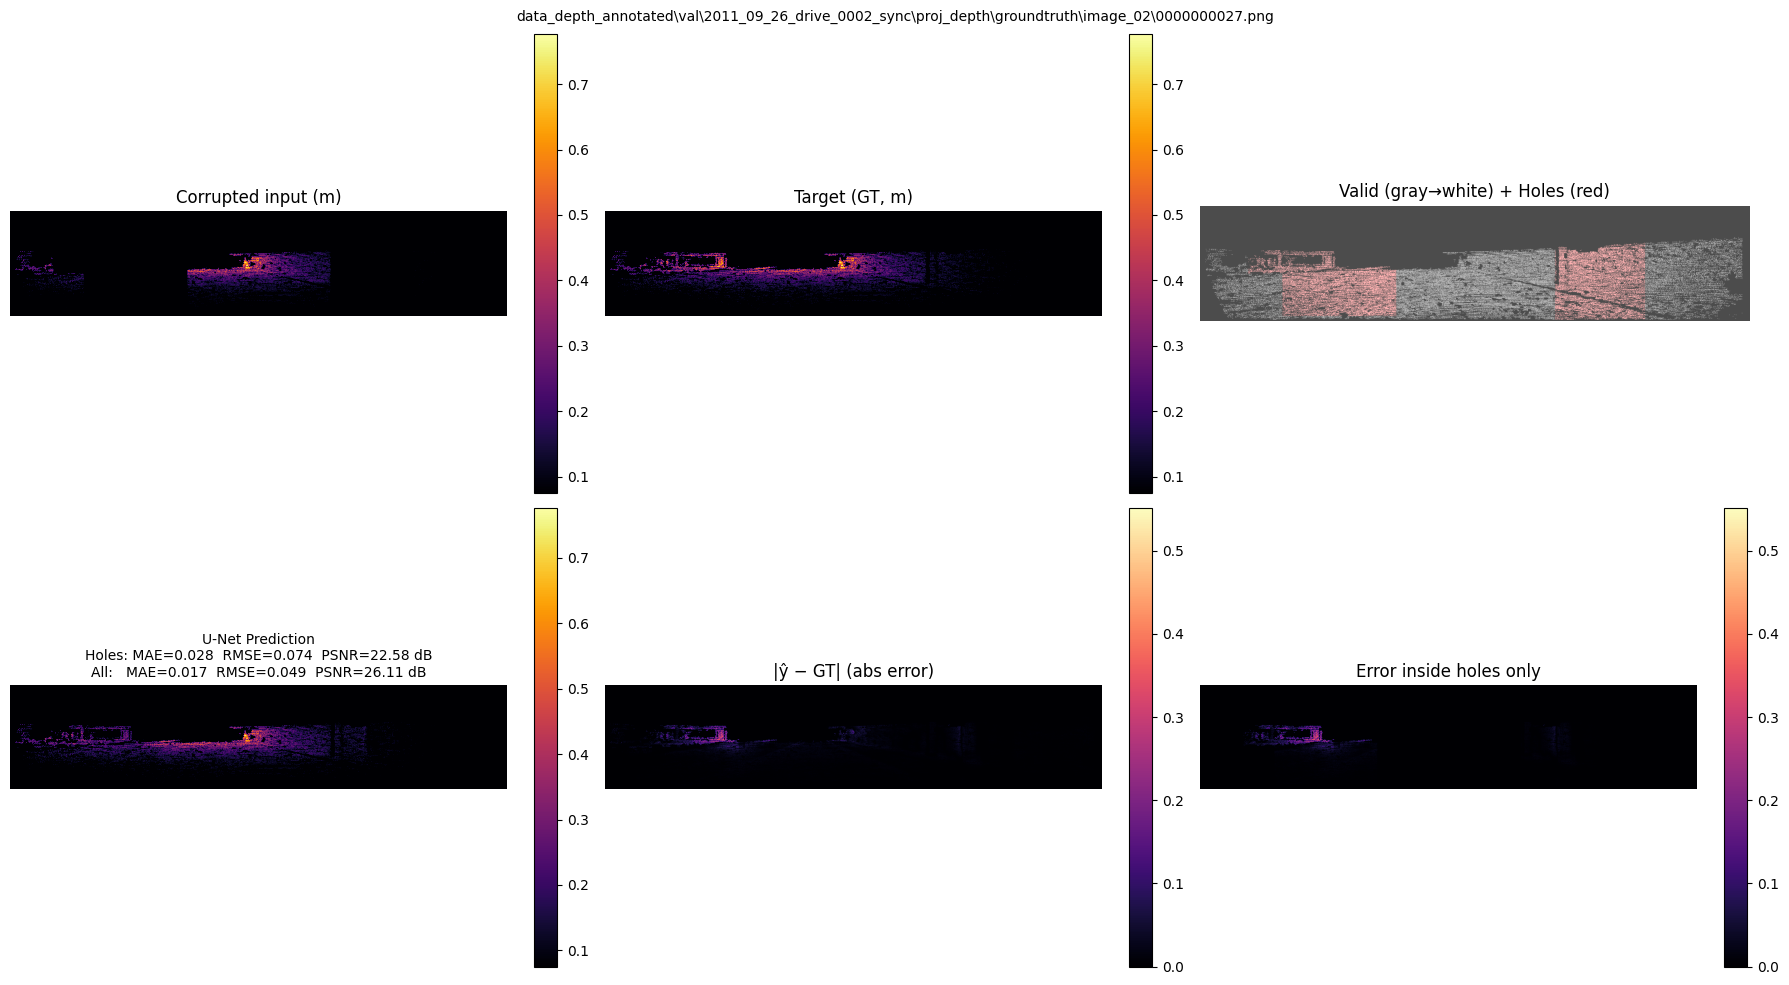

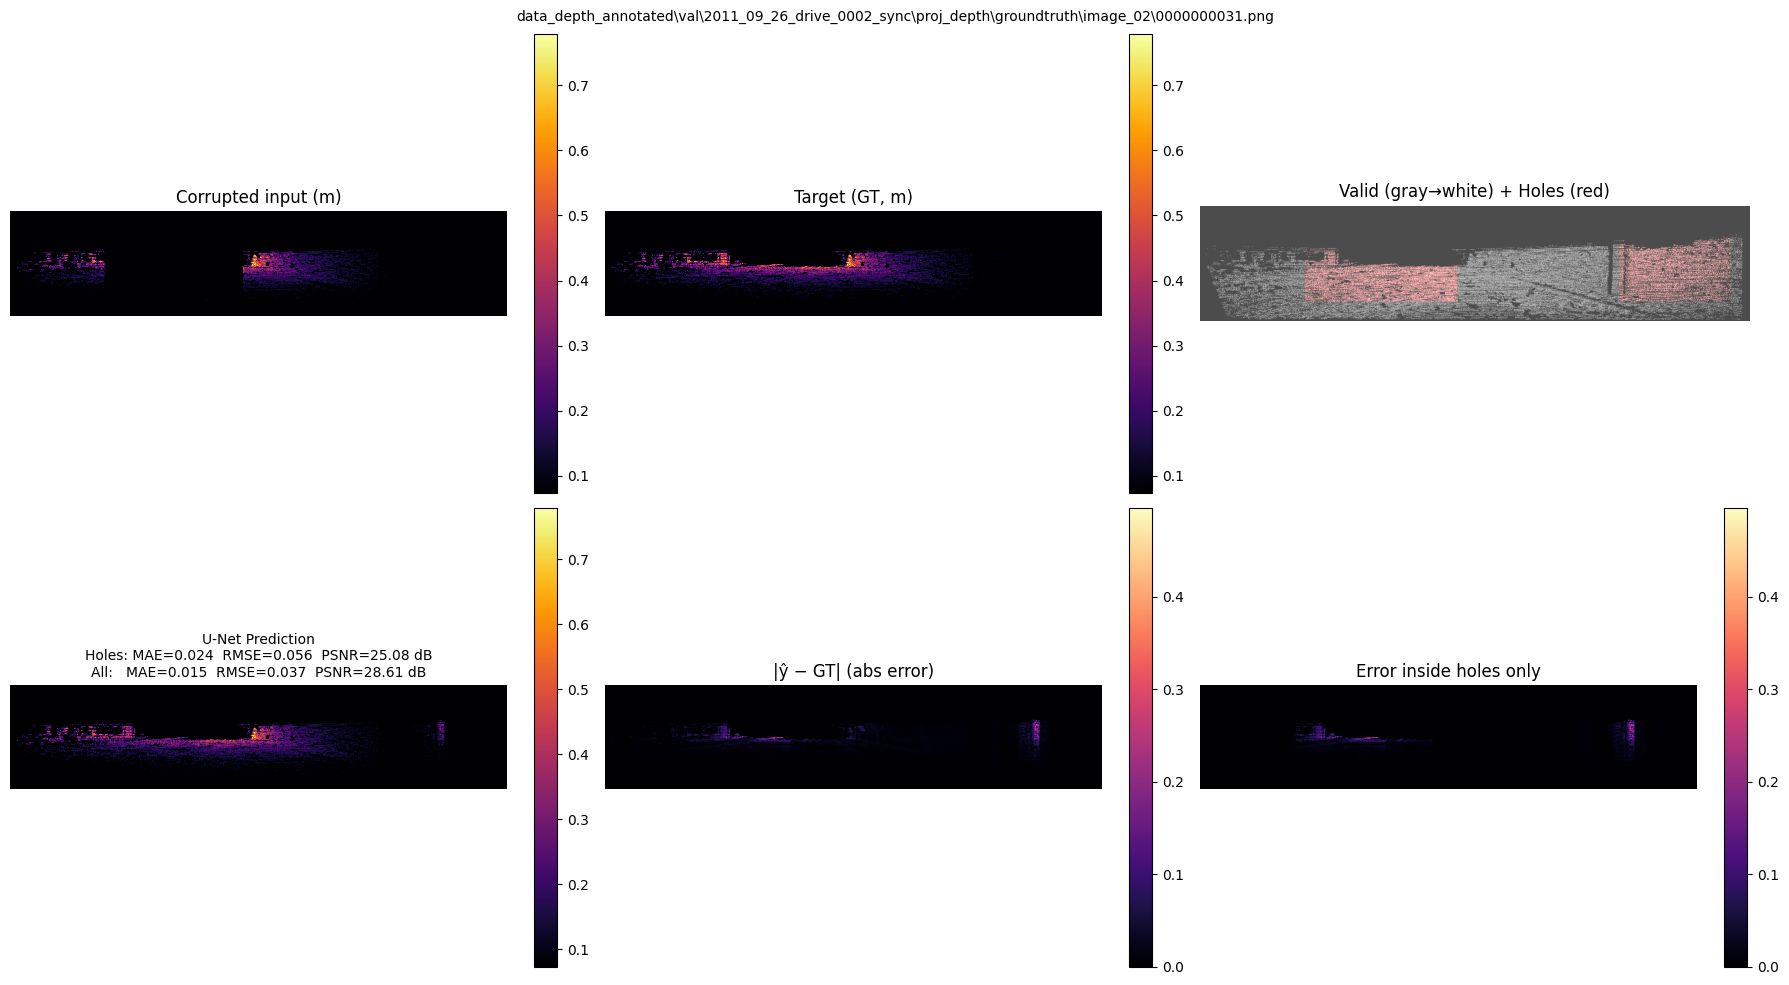

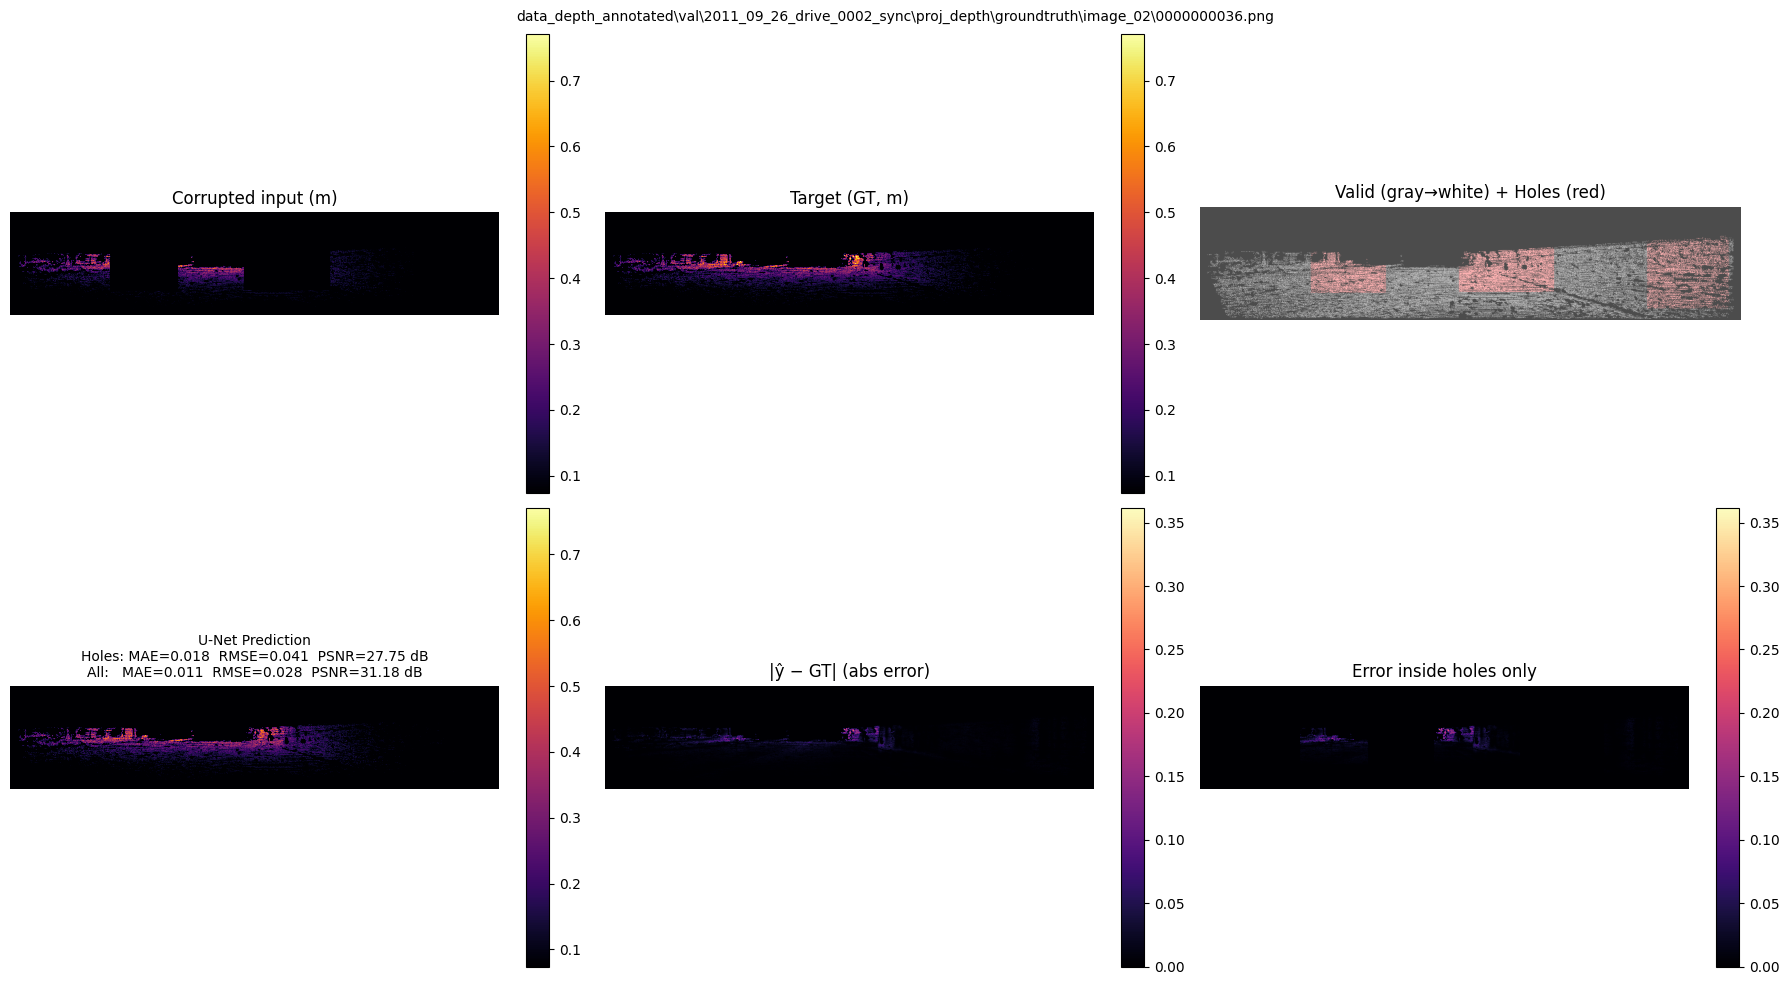

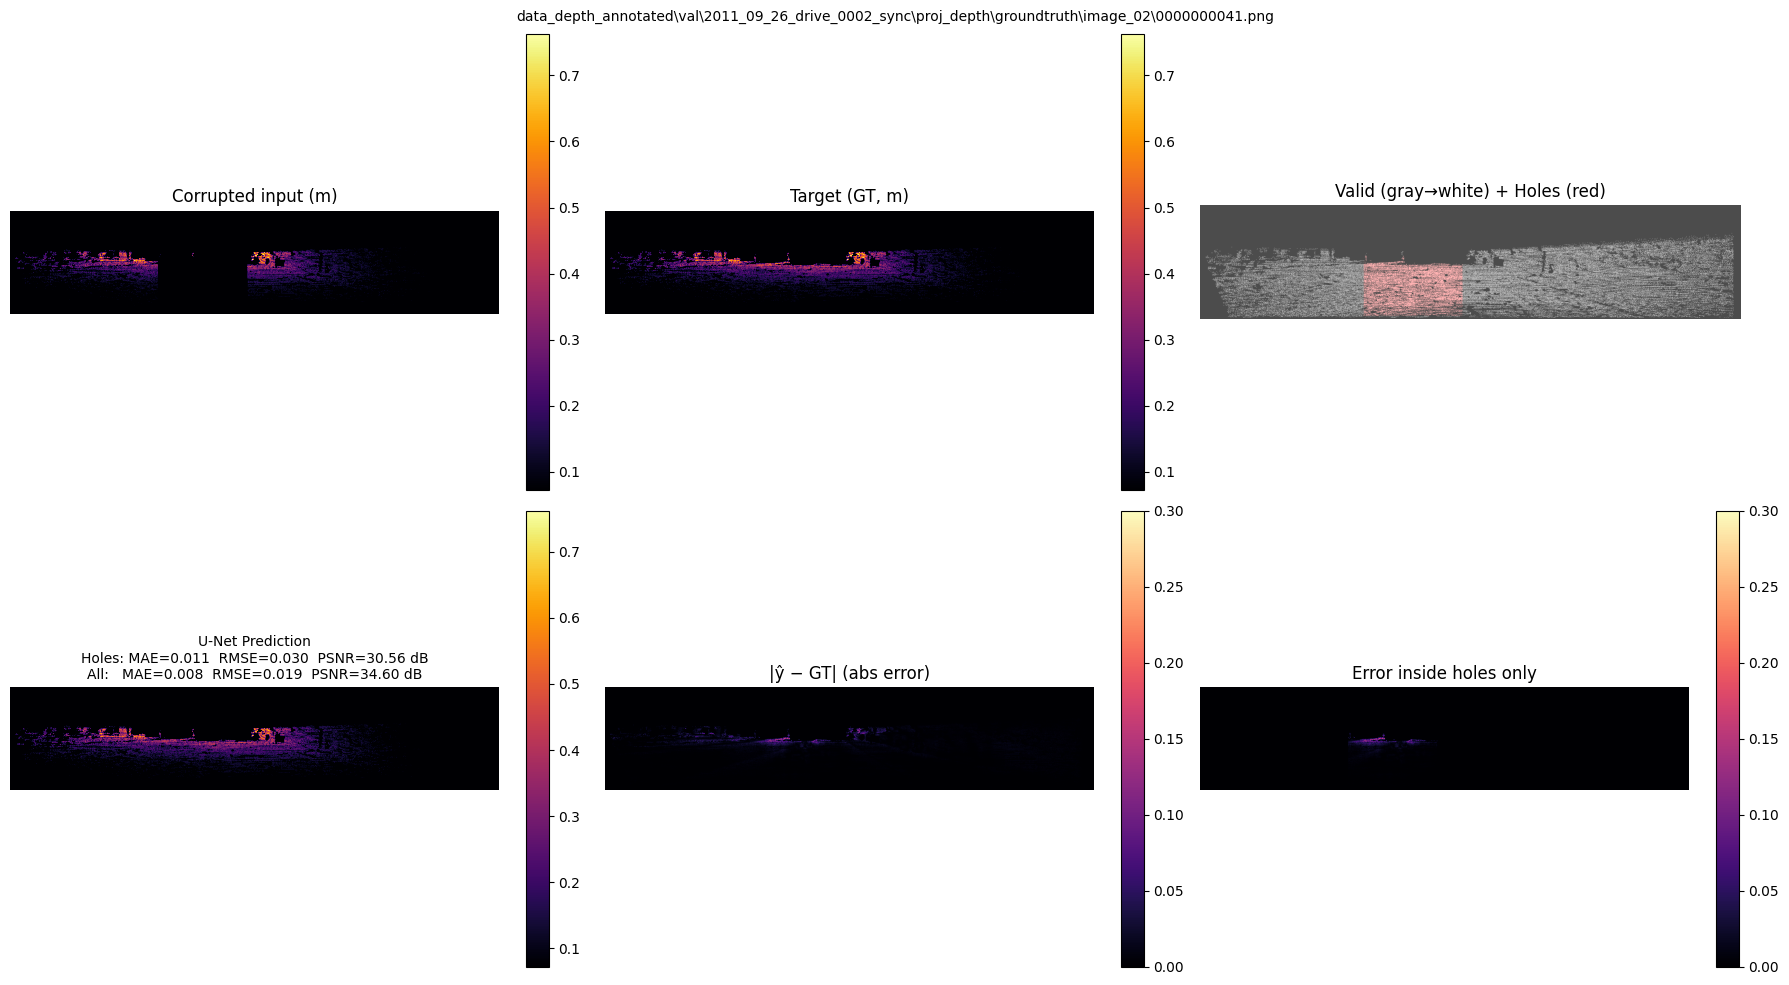

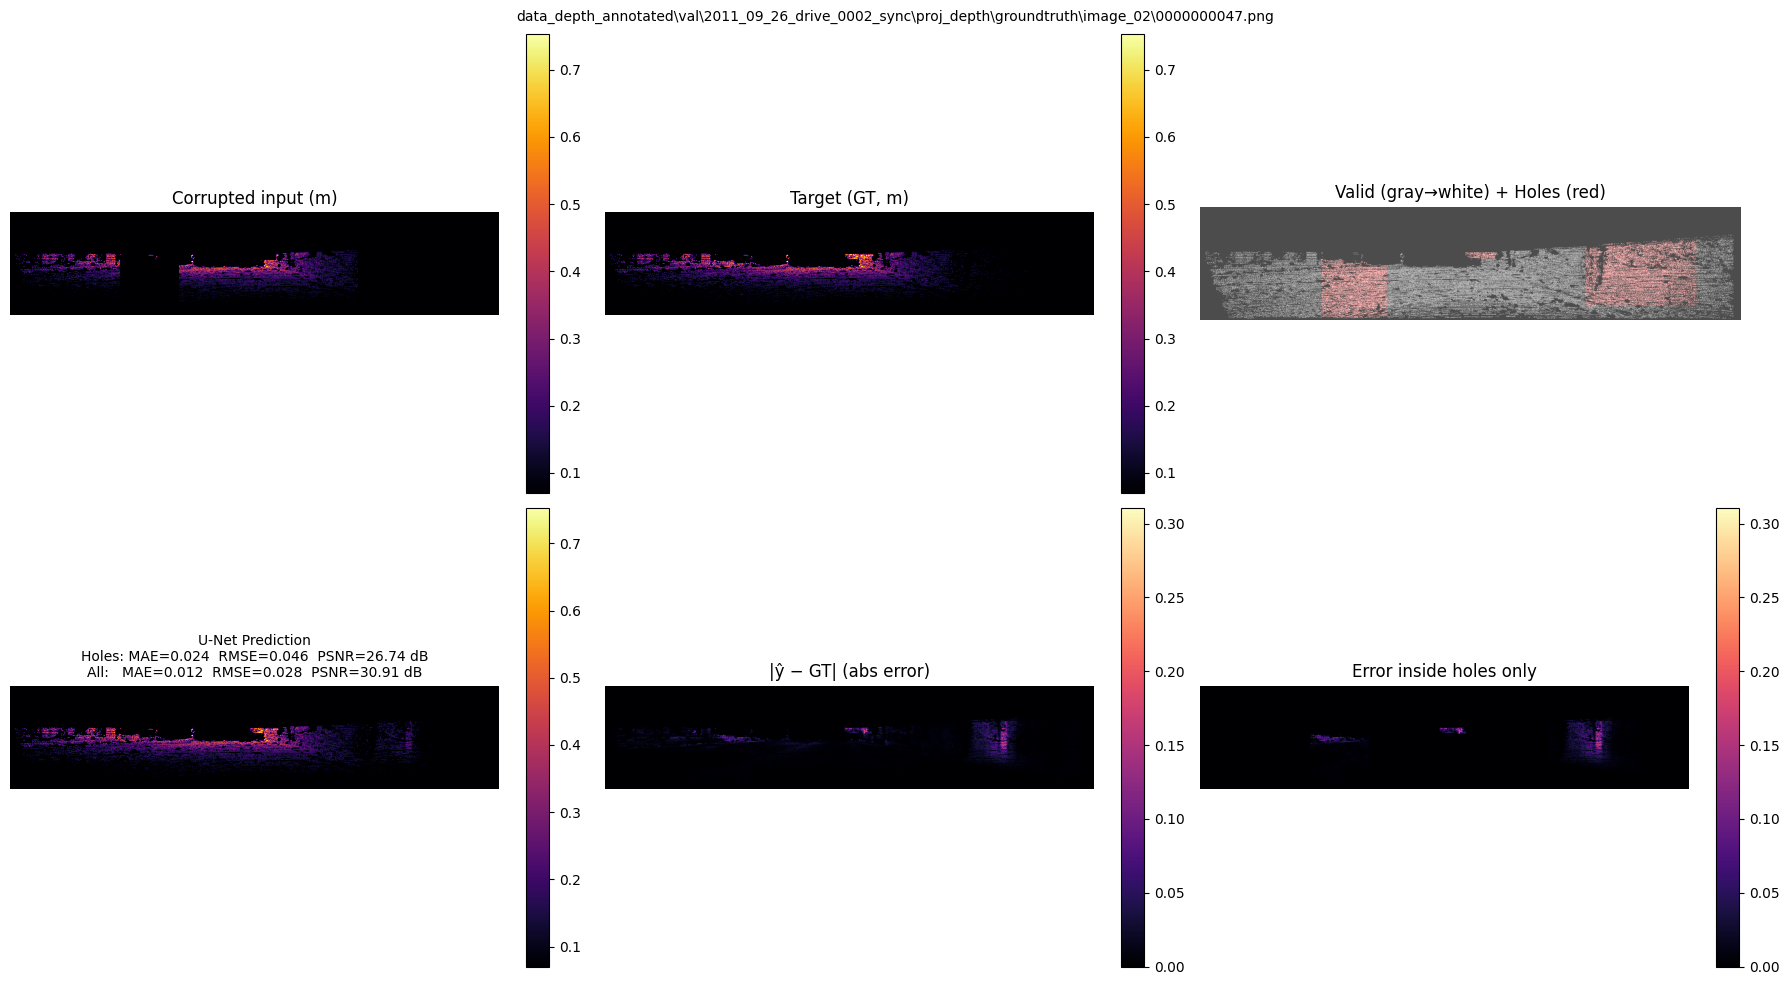

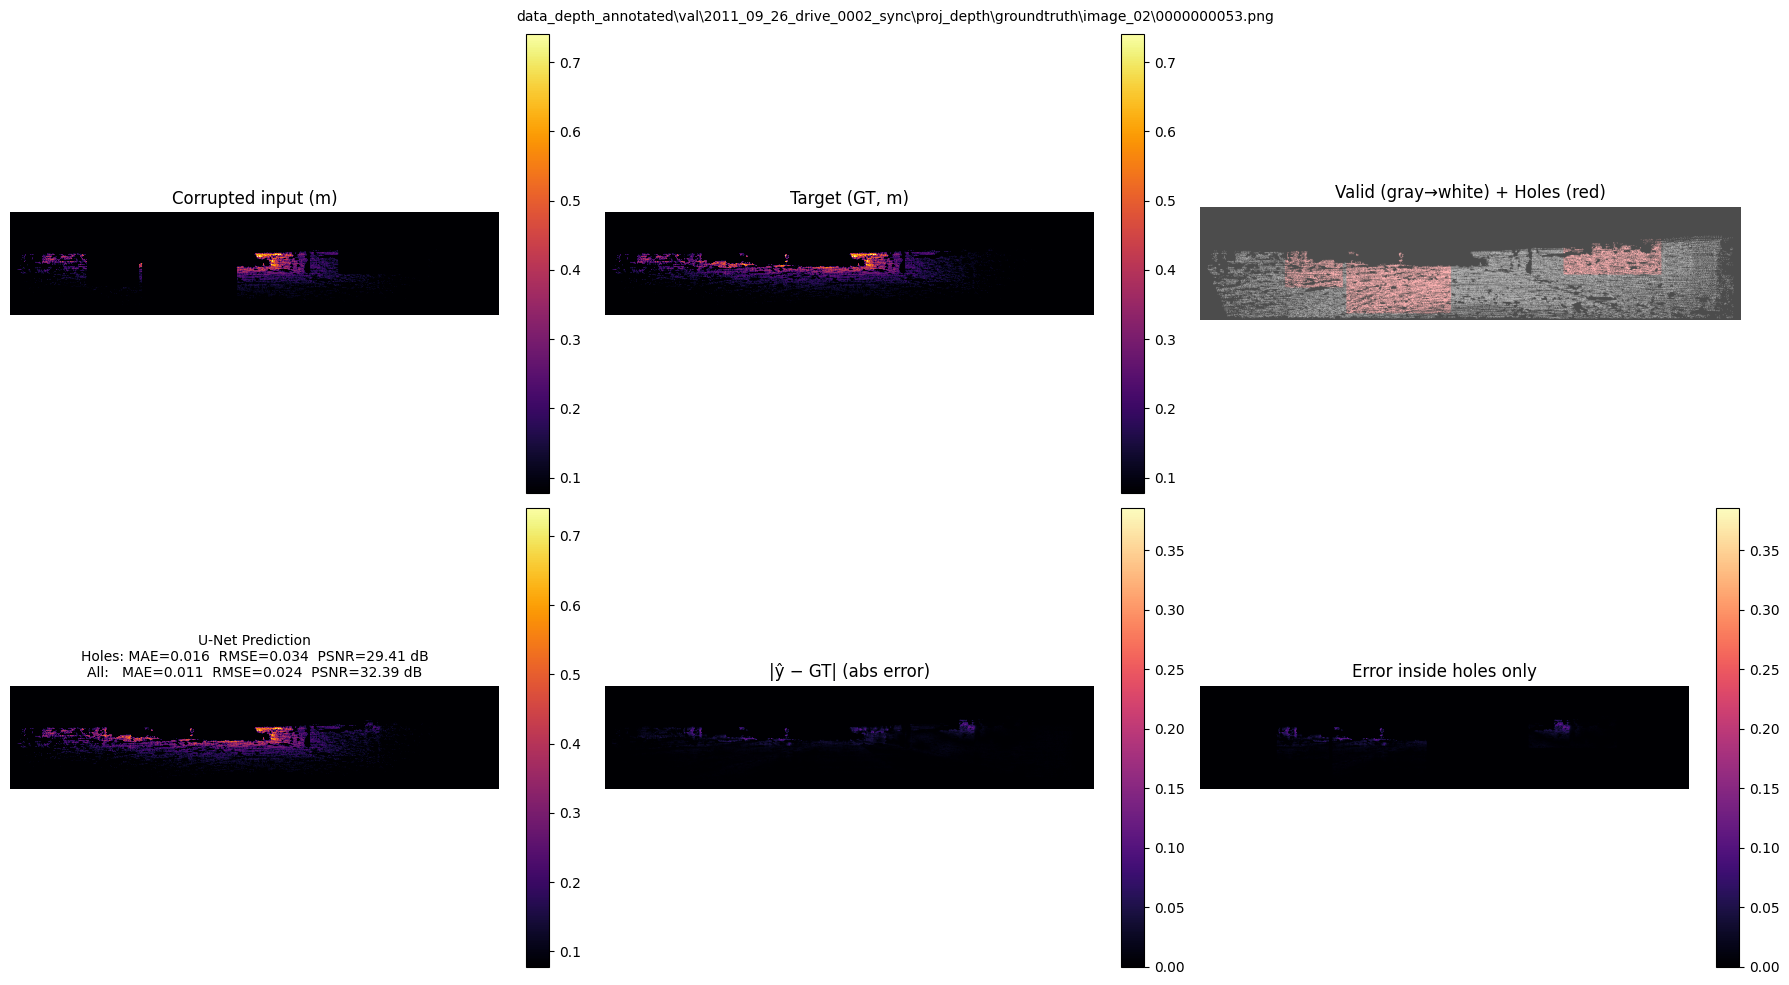

In [ ]:
# ==============================
# U-Net depth inpainting visualizer
# ==============================
import torch, math
import numpy as np
import matplotlib.pyplot as plt

# ---- utility: metrics ----
@torch.no_grad()
def _mae_rmse_psnr(pred, tgt, mask, max_val):
    if mask.sum() == 0:
        return (math.nan, math.nan, math.nan)
    e = (pred - tgt)[mask]
    mae = e.abs().mean().item()
    rmse = torch.sqrt((e**2).mean()).item()
    psnr = float('inf') if rmse == 0 or math.isnan(rmse) else 20.0 * math.log10(max_val / rmse)
    return mae, rmse, psnr

def _overlay_holes(valid_mask, hole_mask):
    """RGB overlay: valid (gray→white), holes (red) where GT exists but input==0."""
    H, W = valid_mask.shape
    overlay = np.zeros((H, W, 3), dtype=np.float32)
    overlay[:] = 0.3
    overlay[valid_mask] = 0.7
    rr, cc = np.where(hole_mask & valid_mask)
    overlay[rr, cc, 0] = 1.0
    return overlay

def _disp_range_from_gt(gt, valid_mask):
    vals = gt[valid_mask]
    if vals.numel() == 0:
        return 0.0, 80.0
    vmin = torch.quantile(vals, 0.01).item()
    vmax = torch.quantile(vals, 0.99).item()
    if vmax <= vmin:
        vmax = vmin + 1.0
    return vmin, vmax

@torch.no_grad()
def visualize_unet_batch(model, val_loader_batch, device=None, normalized=False, max_depth_m=80.0,
                         num_samples=2, save_prefix=None):
    """
    Renders up to 'num_samples' items from a single val batch.
    - normalized=False: meters, PSNR max=80
    - normalized=True:  [0,1], PSNR max=1
    """
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    model.eval()
    
    # total_batches = len(val_loader)


    # batch = next(iter(val_loader))
    batch = val_loader_batch
    inp = batch["input_depth"].to(device)    # (B,1,H,W)
    tgt = batch["target_depth"].to(device)   # (B,1,H,W)
    vm  = batch["valid_mask"].to(device)     # (B,1,H,W) bool
    path_list = batch["path"]
    

    pred = model(inp)

    max_val = 1.0 if normalized else max_depth_m

    B = inp.shape[0] # batch size
    S = min(B, num_samples) 
    
    for i in range(S):
        x  = inp[i,0]    # (H,W)
        y  = tgt[i,0]
        yhat = pred[i,0]
        vmask = vm[i,0]
        holes = (x == 0.0) & vmask

        # metrics (holes and all-valid)
        mae_h, rmse_h, psnr_h = _mae_rmse_psnr(yhat, y, holes, max_val=max_val)
        mae_a, rmse_a, psnr_a = _mae_rmse_psnr(yhat, y, vmask, max_val=max_val)

        # display ranges
        vmin, vmax = _disp_range_from_gt(y, vmask)

        # numpy copies for plotting
        x_disp   = torch.zeros_like(x);   x_disp[vmask] = x[vmask]
        y_disp   = torch.zeros_like(y);   y_disp[vmask] = y[vmask]
        yhat_disp= torch.zeros_like(yhat);yhat_disp[vmask] = yhat[vmask]
        err_abs  = torch.zeros_like(y);   err = (yhat - y).abs(); err_abs[vmask] = err[vmask]

        x_np, y_np, yhat_np = x_disp.cpu().numpy(), y_disp.cpu().numpy(), yhat_disp.cpu().numpy()
        err_np = err_abs.cpu().numpy()
        overlay = _overlay_holes(vmask.cpu().numpy().astype(bool), holes.cpu().numpy().astype(bool))

        fig, axs = plt.subplots(2, 3, figsize=(18, 10))
        fig.suptitle(f"{path_list[i]}", fontsize=10)

        # Top row
        im0 = axs[0,0].imshow(x_np, cmap='inferno', vmin=vmin, vmax=vmax); axs[0,0].set_title("Corrupted input (m)"); axs[0,0].axis('off'); plt.colorbar(im0, ax=axs[0,0], fraction=0.046)
        im1 = axs[0,1].imshow(y_np, cmap='inferno', vmin=vmin, vmax=vmax); axs[0,1].set_title("Target (GT, m)"); axs[0,1].axis('off'); plt.colorbar(im1, ax=axs[0,1], fraction=0.046)
        axs[0,2].imshow(overlay); axs[0,2].set_title("Valid (gray→white) + Holes (red)"); axs[0,2].axis('off')

        # Bottom row
        title_pred = f"U-Net Prediction\nHoles: MAE={mae_h:.3f}  RMSE={rmse_h:.3f}  PSNR={psnr_h:.2f} dB\nAll:   MAE={mae_a:.3f}  RMSE={rmse_a:.3f}  PSNR={psnr_a:.2f} dB"
        im2 = axs[1,0].imshow(yhat_np, cmap='inferno', vmin=vmin, vmax=vmax); axs[1,0].set_title(title_pred, fontsize=10); axs[1,0].axis('off'); plt.colorbar(im2, ax=axs[1,0], fraction=0.046)
        im3 = axs[1,1].imshow(err_np, cmap='magma'); axs[1,1].set_title(f"|ŷ − GT| (abs error)"); axs[1,1].axis('off'); plt.colorbar(im3, ax=axs[1,1], fraction=0.046)
    
        # difference overlay only inside holes (zero elsewhere)
        diff_holes = torch.zeros_like(y); diff_holes[holes] = err[holes]
        im4 = axs[1,2].imshow(diff_holes.cpu().numpy(), cmap='magma'); axs[1,2].set_title("Error inside holes only"); axs[1,2].axis('off'); plt.colorbar(im4, ax=axs[1,2], fraction=0.046)

        plt.tight_layout()
        if save_prefix:
            outpath = f"{save_prefix}_sample{i}.png"
            plt.savefig(outpath, dpi=200, bbox_inches='tight')
            print(f"Saved {outpath}")
        plt.show()

# -------- load best checkpoint and visualize ----------
device = "cuda" if torch.cuda.is_available() else "cpu"

# Recreate the model exactly as during training
viz_model = DepthAutoencoder(in_ch=1, base_ch=32).to(device)
# ckpt = torch.load("unet_depth_epochs6_frac25.pt", map_location=device)
ckpt = torch.load("unet_depth_inpaint_best.pt", map_location=device)
viz_model.load_state_dict(ckpt["model"])

# Set this to match your dataset 'normalize' flag:
normalized_flag = True  

it = iter(test_loader)
batches_to_visualize = 10
for i in range(batches_to_visualize):
    test_batch = next(it)
    visualize_unet_batch(viz_model, test_batch, device=device,
                    normalized=normalized_flag, max_depth_m=80.0,
                    num_samples=1, save_prefix=None)
    



##############################################################################
# TODO: ALSO VISUALIZE VALID MASK THAT IS RETURNED FROM THE U-NET PREDICTION #
##############################################################################
